# LIBRARY IMPORT


In [3]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import librosa
import librosa.display
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import plotly.figure_factory as ff
import seaborn as sns
import IPython
import tensorflow.keras.layers as L
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical  # Fixed import
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
import re
import itertools
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import os
from tkinter import Tk, Button, Label, filedialog
import tkinter as tk
from tkinter import ttk
from PIL import Image, ImageTk
import requests
import io
import base64
import json

In [4]:
import zipfile
import os

zip_path = '/content/Ravdess.zip'
extract_to = '/content/'

os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print(f'Contents extracted to: {extract_to}')

Contents extracted to: /content/


In [5]:
pd.set_option('display.max_columns', None)       # Show all columns
pd.set_option('display.max_rows', None)          # Show all rows (optional)
pd.set_option('display.max_colwidth', None)      # Show full content in each cell
pd.set_option('display.width', None)             # Let output use full width of the notebook
pd.set_option('display.expand_frame_repr', False) # Prevent breaking wide DataFrames into multiple lines

# RAVDESS FILE

In [6]:
Ravdess_Path = 'Ravdess/audio_speech_actors_01-24'
ravdess=[]
for directory in os.listdir(Ravdess_Path):
    actors=os.listdir(os.path.join(Ravdess_Path,directory))
    for wav in actors:
        emotion=wav.partition('.wav')[0].split('-')
        emotion_number=int(emotion[2])
        ravdess.append((emotion_number,os.path.join(Ravdess_Path,directory,wav)))
Ravdess_df=pd.DataFrame.from_dict(ravdess)
Ravdess_df.rename(columns={0:'Emotion',1:'File_Path'},inplace=True)
Ravdess_df['Emotion'].replace({1:'neutral', 2:'neutral', 3:'happy', 4:'sad', 5:'angry', 6:'fear', 7:'disgust', 8:'surprise'},inplace=True)
Ravdess_df.sample(10)

,Emotion,File_Path
390,disgust,Ravdess/audio_speech_actors_01-24/Actor_16/03-01-07-01-01-01-16.wav
1061,angry,Ravdess/audio_speech_actors_01-24/Actor_17/03-01-05-02-01-02-17.wav
750,angry,Ravdess/audio_speech_actors_01-24/Actor_20/03-01-05-02-02-02-20.wav
1437,neutral,Ravdess/audio_speech_actors_01-24/Actor_18/03-01-02-02-01-01-18.wav
269,angry,Ravdess/audio_speech_actors_01-24/Actor_08/03-01-05-01-02-01-08.wav
1023,sad,Ravdess/audio_speech_actors_01-24/Actor_17/03-01-04-02-01-02-17.wav
1017,sad,Ravdess/audio_speech_actors_01-24/Actor_21/03-01-04-02-02-02-21.wav
598,sad,Ravdess/audio_speech_actors_01-24/Actor_23/03-01-04-02-02-01-23.wav
1130,angry,Ravdess/audio_speech_actors_01-24/Actor_24/03-01-05-01-02-01-24.wav
1428,angry,Ravdess/audio_speech_actors_01-24/Actor_18/03-01-05-01-01-02-18.wav


In [7]:
Ravdess_df.shape

(1440, 2)

In [8]:
Ravdess_df['Emotion'].unique()

array(['neutral', 'happy', 'angry', 'fear', 'surprise', 'sad', 'disgust'],
      dtype=object)

In [9]:
main_df=pd.concat([Ravdess_df],axis=0)
main_df.shape

(1440, 2)

In [10]:
main_df.head(15)

,Emotion,File_Path
0,neutral,Ravdess/audio_speech_actors_01-24/Actor_12/03-01-02-01-01-02-12.wav
1,happy,Ravdess/audio_speech_actors_01-24/Actor_12/03-01-03-01-02-02-12.wav
2,angry,Ravdess/audio_speech_actors_01-24/Actor_12/03-01-05-01-01-01-12.wav
3,angry,Ravdess/audio_speech_actors_01-24/Actor_12/03-01-05-01-02-01-12.wav
4,happy,Ravdess/audio_speech_actors_01-24/Actor_12/03-01-03-02-01-01-12.wav
5,angry,Ravdess/audio_speech_actors_01-24/Actor_12/03-01-05-02-01-02-12.wav
6,fear,Ravdess/audio_speech_actors_01-24/Actor_12/03-01-06-01-01-02-12.wav
7,neutral,Ravdess/audio_speech_actors_01-24/Actor_12/03-01-02-02-02-02-12.wav
8,surprise,Ravdess/audio_speech_actors_01-24/Actor_12/03-01-08-02-01-02-12.wav
9,angry,Ravdess/audio_speech_actors_01-24/Actor_12/03-01-05-02-02-02-12.wav


In [11]:
main_df.tail(15)

,Emotion,File_Path
1425,neutral,Ravdess/audio_speech_actors_01-24/Actor_18/03-01-02-01-01-02-18.wav
1426,disgust,Ravdess/audio_speech_actors_01-24/Actor_18/03-01-07-01-01-01-18.wav
1427,fear,Ravdess/audio_speech_actors_01-24/Actor_18/03-01-06-01-02-02-18.wav
1428,angry,Ravdess/audio_speech_actors_01-24/Actor_18/03-01-05-01-01-02-18.wav
1429,neutral,Ravdess/audio_speech_actors_01-24/Actor_18/03-01-02-02-01-02-18.wav
1430,happy,Ravdess/audio_speech_actors_01-24/Actor_18/03-01-03-01-02-02-18.wav
1431,sad,Ravdess/audio_speech_actors_01-24/Actor_18/03-01-04-01-01-01-18.wav
1432,fear,Ravdess/audio_speech_actors_01-24/Actor_18/03-01-06-01-01-01-18.wav
1433,surprise,Ravdess/audio_speech_actors_01-24/Actor_18/03-01-08-01-01-02-18.wav
1434,happy,Ravdess/audio_speech_actors_01-24/Actor_18/03-01-03-02-02-01-18.wav


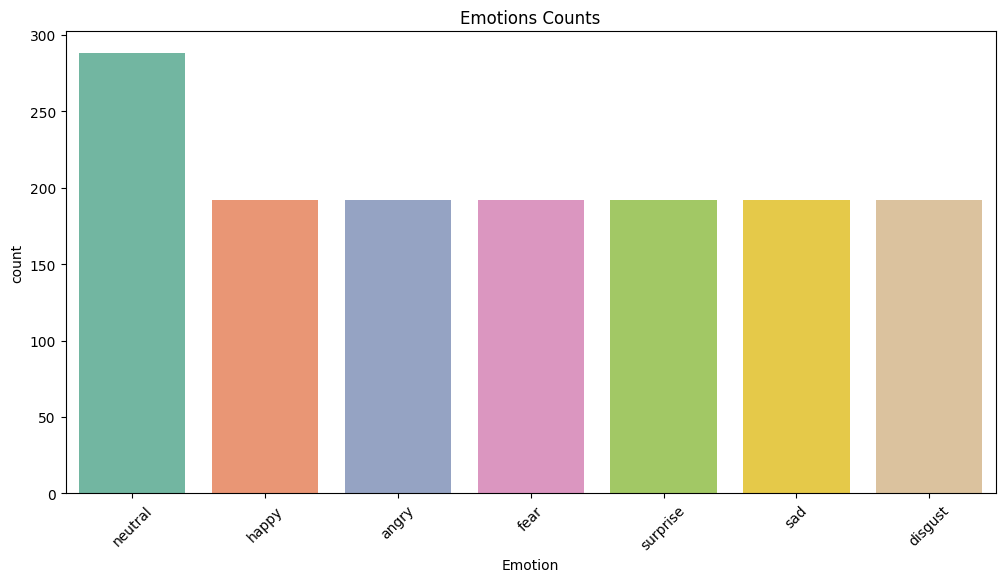

In [12]:
plt.figure(figsize=(12,6))
plt.title('Emotions Counts')
emotions=sns.countplot(x='Emotion',data=main_df,palette='Set2')
emotions.set_xticklabels(emotions.get_xticklabels(),rotation=45)
plt.show()

In [13]:
emotion_names=main_df['Emotion'].unique()

In [14]:
colors={'disgust':'#804E2D','happy':'#F19C0E','sad':'#478FB8','neutral':'#4CB847','fear':'#7D55AA','angry':'#C00808','surprise':'#EE00FF'}

In [15]:
def wave_plot(data,sr,emotion,color):
    plt.figure(figsize=(12,5))
    plt.title(f'{emotion} emotion for waveplot',size=17)
    librosa.display.waveshow(y=data,sr=sr,color=color)

In [16]:
def spectogram(data,sr,emotion):
    audio=librosa.stft(data)
    audio_db=librosa.amplitude_to_db(abs(audio))
    plt.figure(figsize=(12,5))
    plt.title(f'{emotion} emotion for spectogram',size=17)
    librosa.display.specshow(audio_db,sr=sr,x_axis='time',y_axis='hz')

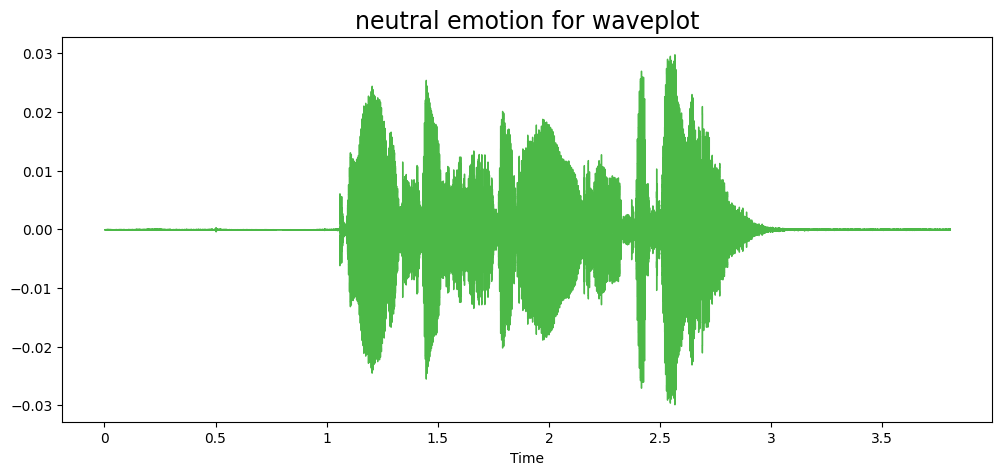

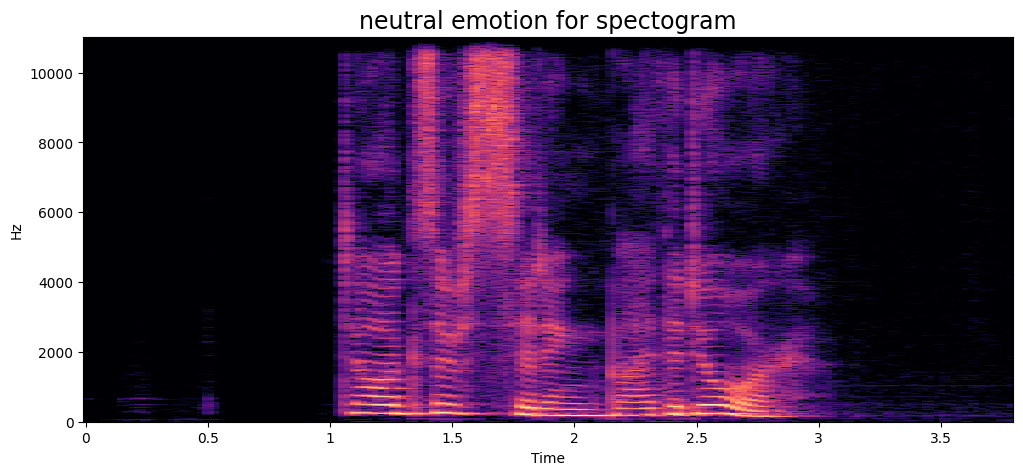

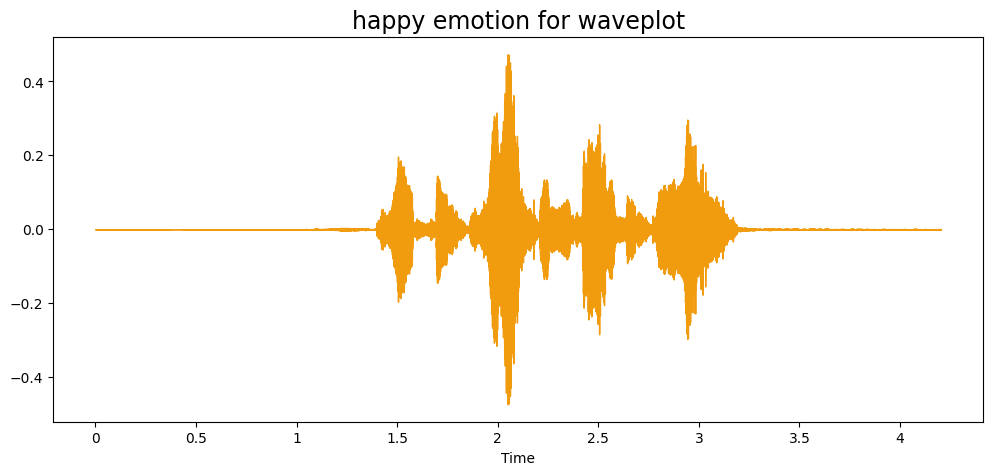

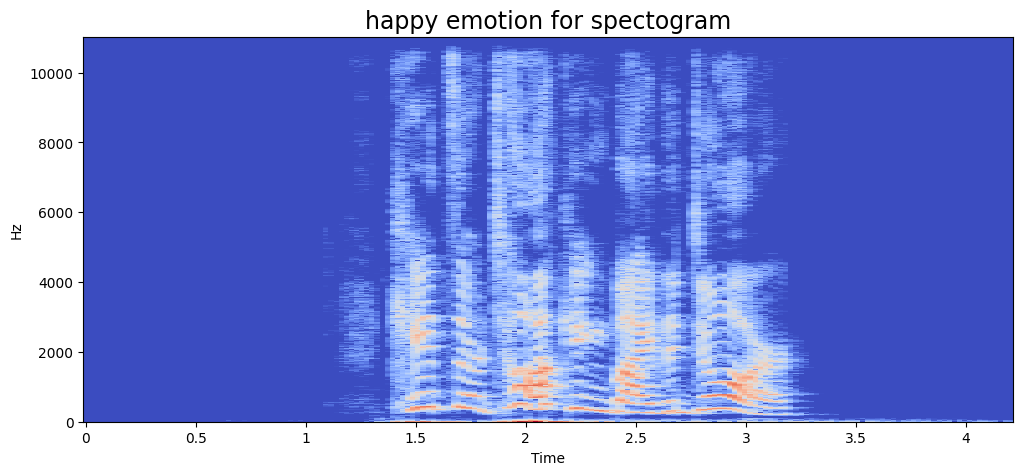

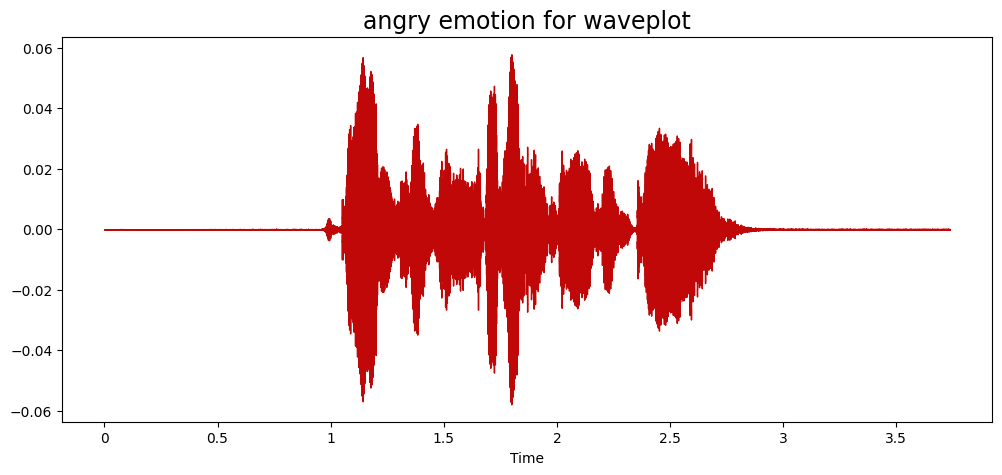

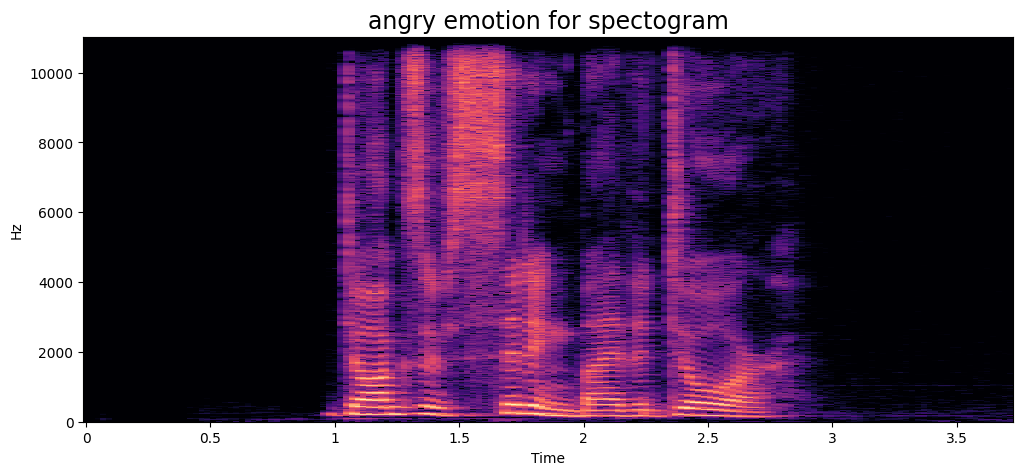

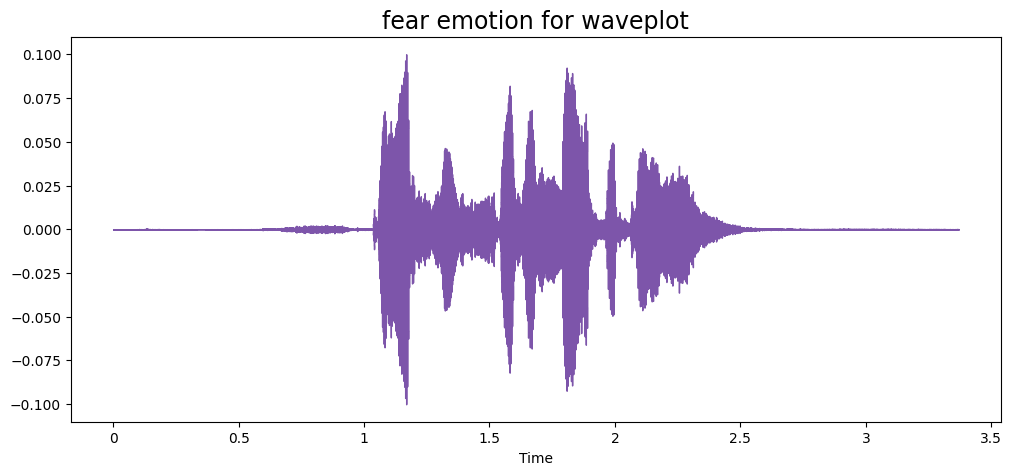

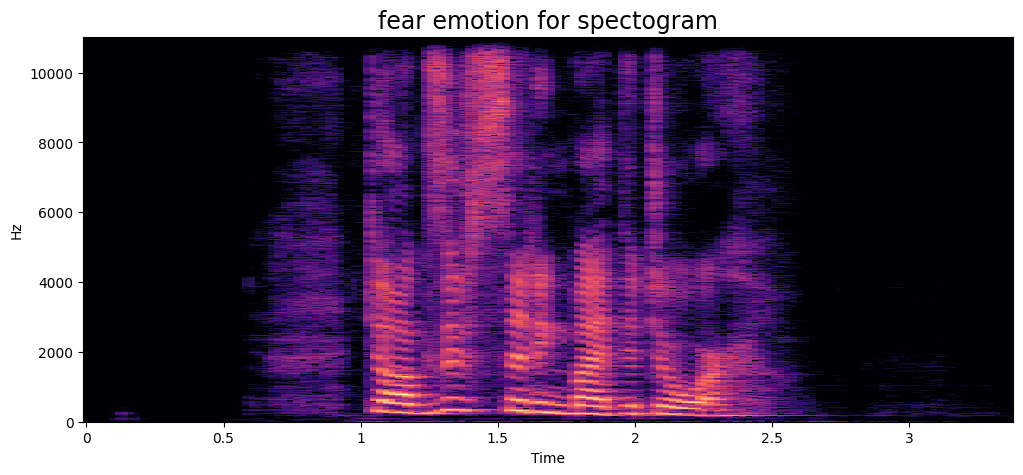

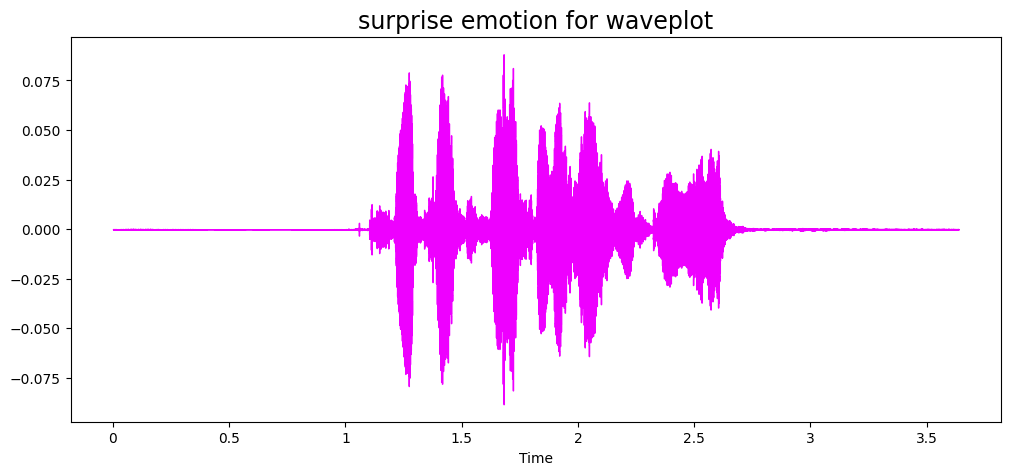

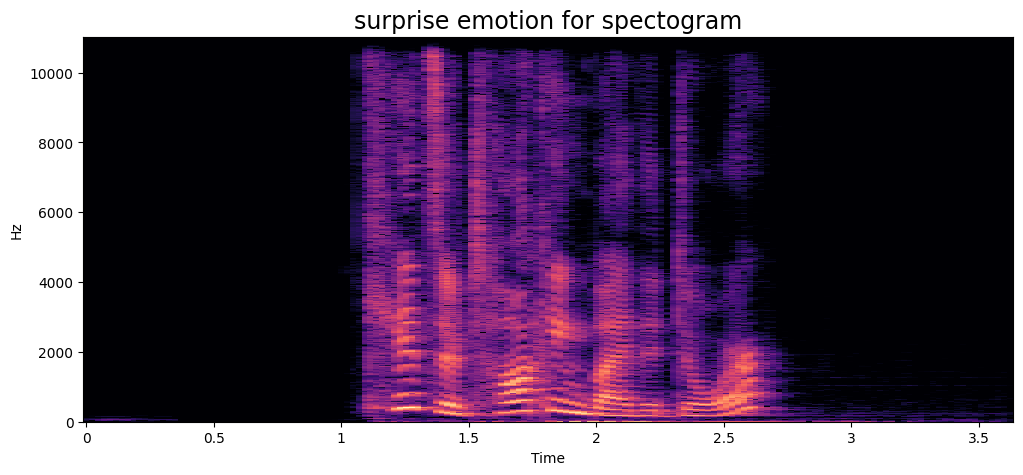

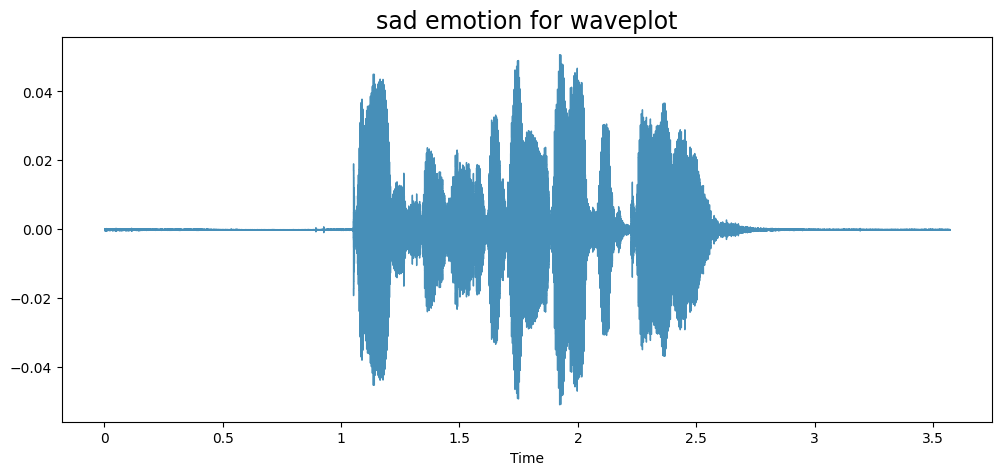

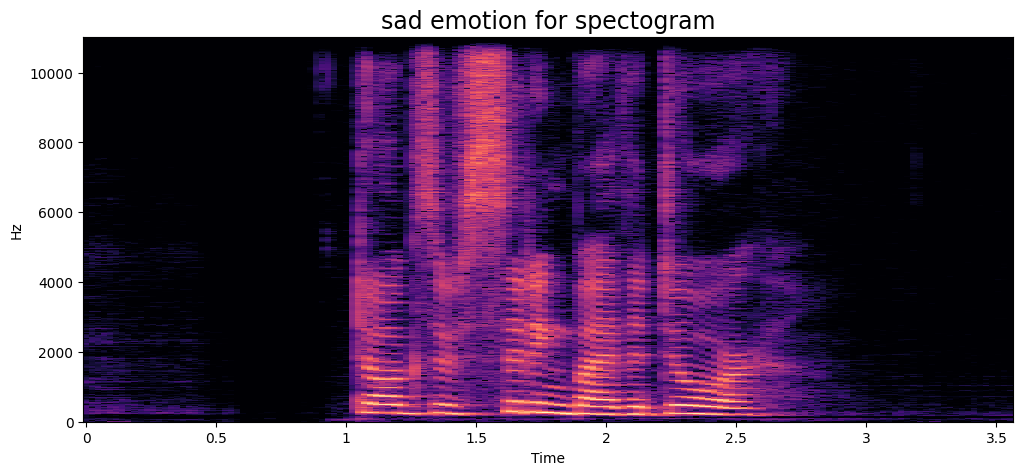

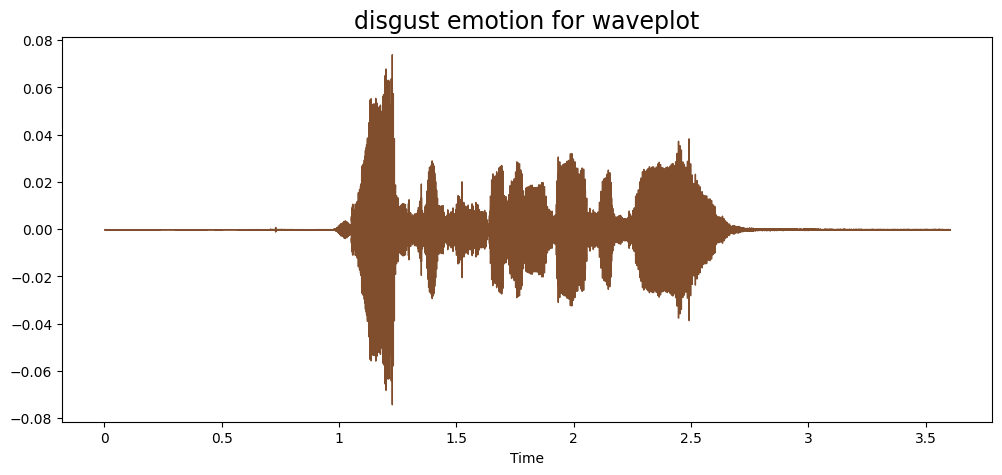

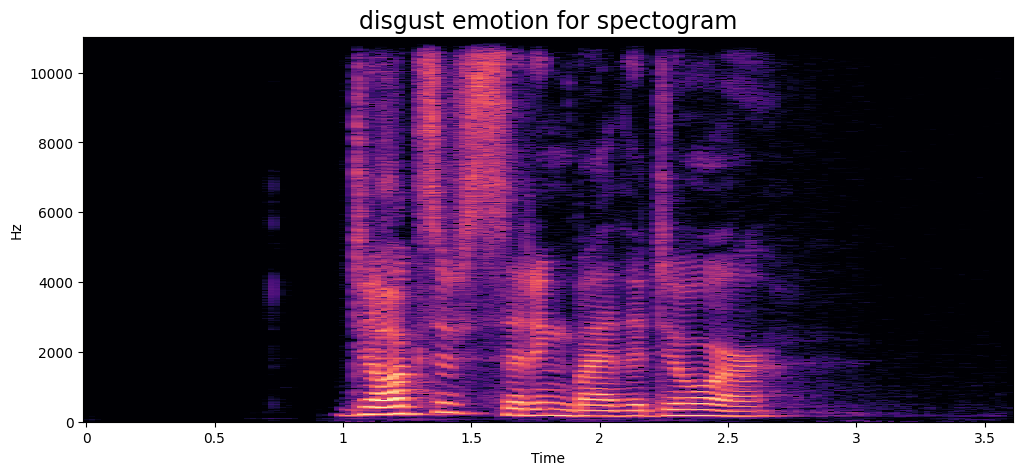

In [17]:
audio_path=[]
for emotion in emotion_names:
    path=np.array(main_df['File_Path'][main_df['Emotion']==emotion])[1]
    data,sr=librosa.load(path)
    wave_plot(data,sr,emotion,colors[emotion])
    spectogram(data,sr,emotion)
    audio_path.append(path)

In [18]:
print('Neutral Audio Sample\n')
IPython.display.Audio(audio_path[0])

Neutral Audio Sample



In [19]:
print('Surprise Audio Sample\n')
IPython.display.Audio(audio_path[1])

Surprise Audio Sample



In [20]:
print('Happy Audio Sample\n')
IPython.display.Audio(audio_path[2])

Happy Audio Sample



In [21]:
print('Fear Audio Sample\n')
IPython.display.Audio(audio_path[3])

Fear Audio Sample



In [22]:
print('Sad Audio Sample\n')
IPython.display.Audio(audio_path[4])

Sad Audio Sample



In [23]:
print('Angry Audio Sample\n')
IPython.display.Audio(audio_path[5])

Angry Audio Sample



In [24]:
print('Disgust Audio Sample\n')
IPython.display.Audio(audio_path[6])

Disgust Audio Sample



# DATA AUGMENTATION


In [25]:
def add_noise(data,random=False,rate=0.035,threshold=0.075):
    if random:
        rate=np.random.random()*threshold
    noise=rate*np.random.uniform()*np.amax(data)
    augmented_data=data+noise*np.random.normal(size=data.shape[0])
    return augmented_data

def shifting(data,rate=1000):
    augmented_data=int(np.random.uniform(low=-5,high=5)*rate)
    augmented_data=np.roll(data,augmented_data)
    return augmented_data

def pitching(data,sr,pitch_factor=0.7,random=False):
    if random:
        pitch_factor=np.random.random() * pitch_factor
    return librosa.effects.pitch_shift(y=data,sr=sr,n_steps=pitch_factor)

def stretching(data,rate=0.8):
    return librosa.effects.time_stretch(y=data,rate=rate)

In [26]:
data,sr=librosa.load(audio_path[6])

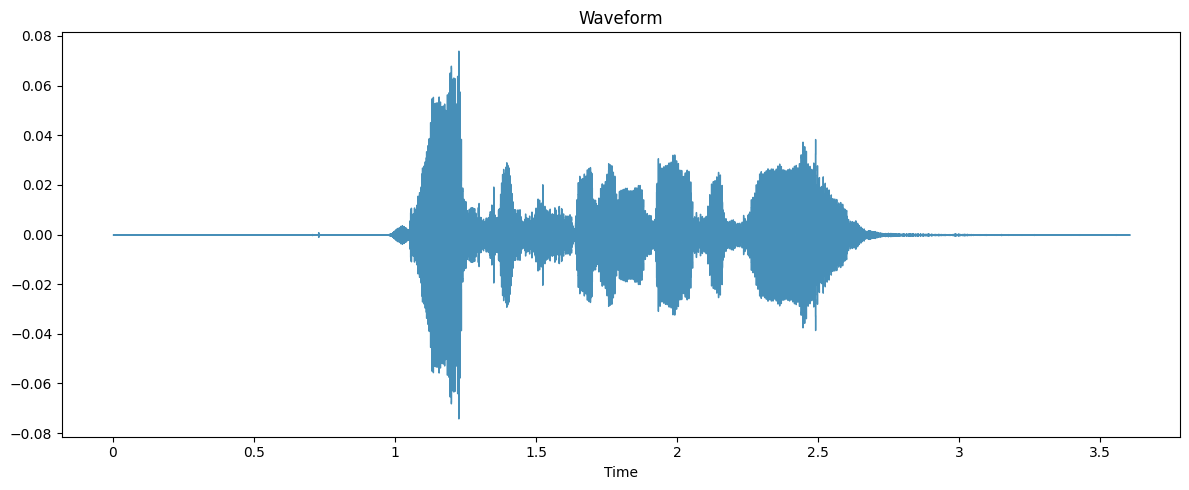

In [27]:
#ORIGINAL AUDIO
plt.figure(figsize=(12,5))
librosa.display.waveshow(y=data, sr=sr, color='#478FB8')  # Use named parameters
plt.title('Waveform')
plt.tight_layout()
plt.show()
IPython.display.Audio(audio_path[6])

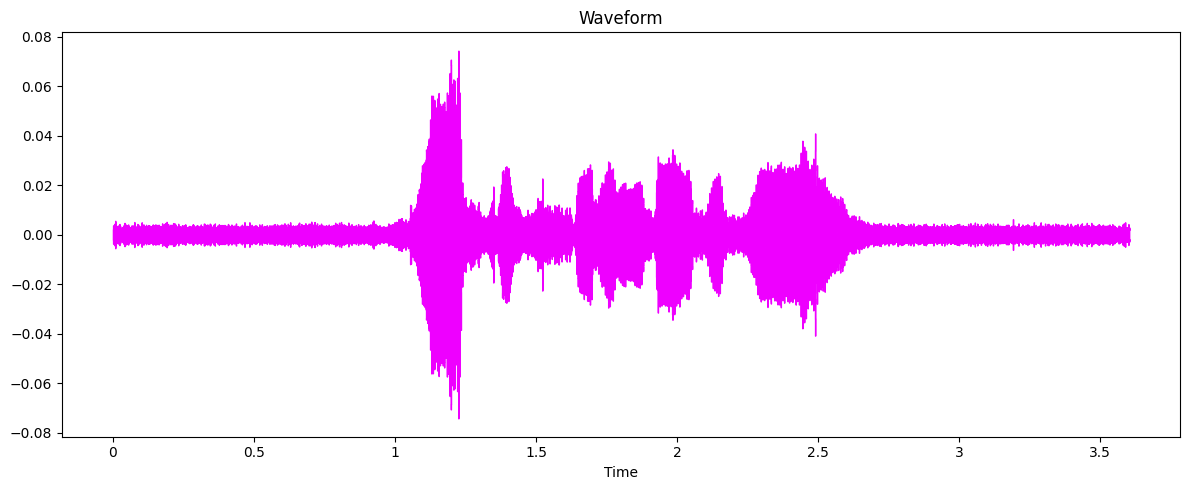

In [28]:
#NOISED AUDIO
noised_audio = add_noise(data)
plt.figure(figsize=(12,5))
librosa.display.waveshow(y=noised_audio, sr=sr, color='#EE00FF')  # Use named parameters
plt.title('Waveform')
plt.tight_layout()
plt.show()
IPython.display.Audio(noised_audio, rate=sr)

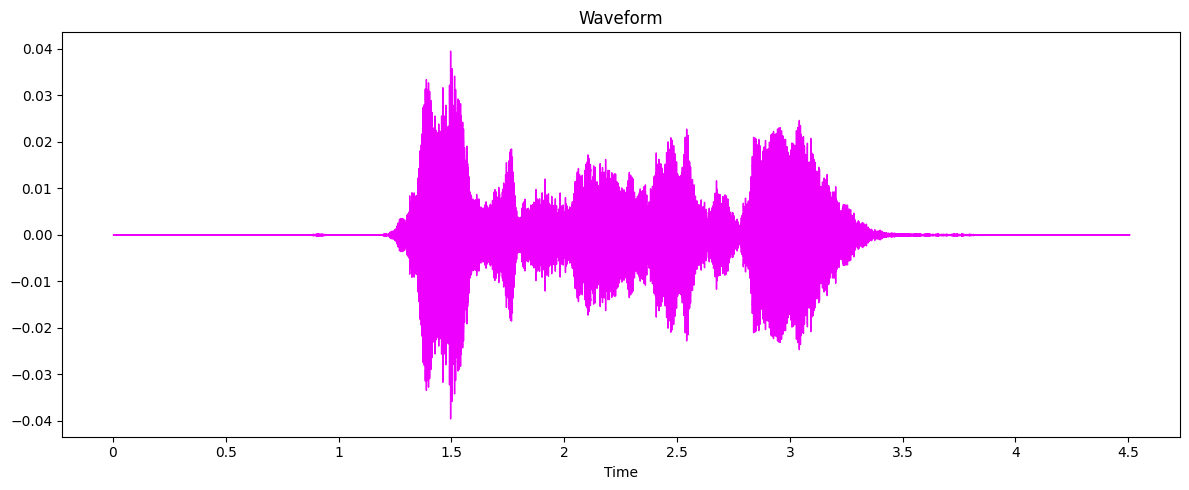

In [29]:
#STRETCHED AUDIO
stretched_audio = stretching(data)
plt.figure(figsize=(12, 5))
librosa.display.waveshow(y=stretched_audio, sr=sr, color='#EE00FF')
plt.title('Waveform')
plt.tight_layout()
plt.show()
IPython.display.Audio(stretched_audio, rate=sr)

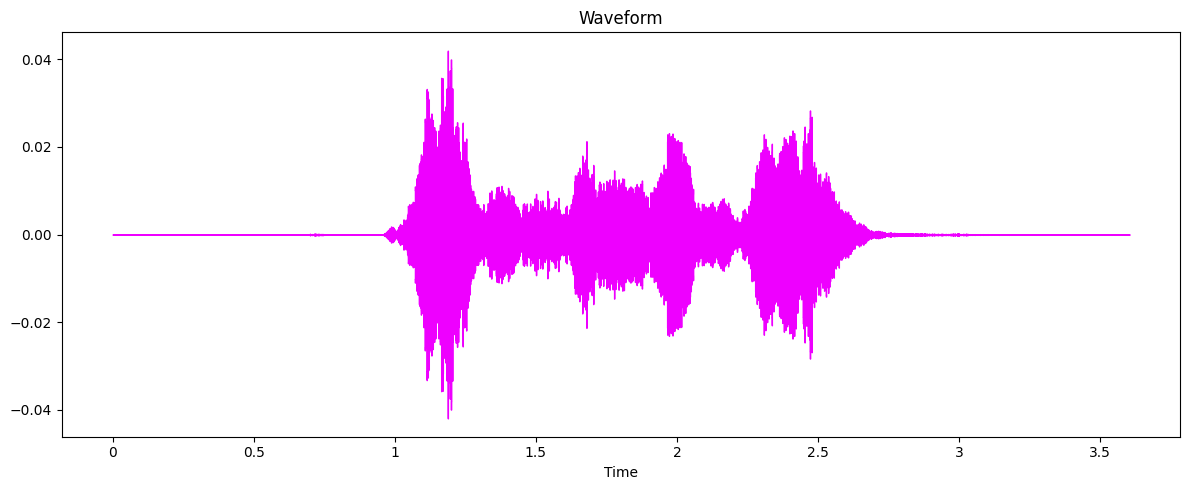

In [30]:
#PITCHED AUDIO
pitched_audio=pitching(data,sr)
plt.figure(figsize=(12,5))
librosa.display.waveshow(y=pitched_audio, sr=sr, color='#EE00FF')
plt.title('Waveform')
plt.tight_layout()
plt.show()
IPython.display.Audio(pitched_audio,rate=sr)

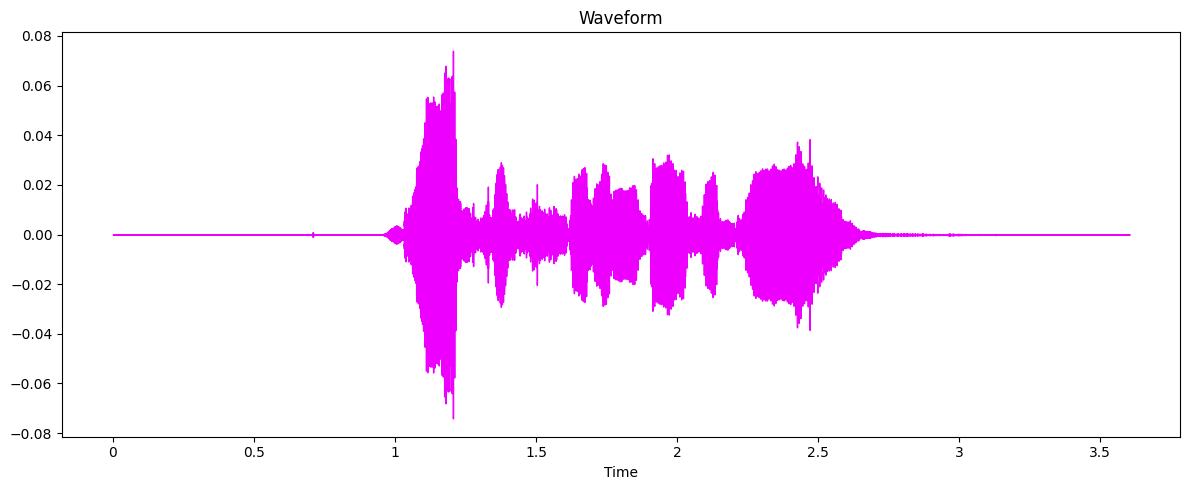

In [31]:
#SHIFTED AUDIO
shifted_audio=shifting(data)
plt.figure(figsize=(12,5))
librosa.display.waveshow(y=shifted_audio,sr=sr,color='#EE00FF')
plt.title('Waveform')
plt.tight_layout()
plt.show()
IPython.display.Audio(shifted_audio,rate=sr)

# FEATURE EXTRACTION
USING MFCC

In [32]:
def mfcc(data, sr, frame_length=2048, hop_length=512, flatten:bool=True):
    """Extract Mel-Frequency Cepstral Coefficients feature"""
    mfcc_feat = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=13, hop_length=hop_length, n_fft=frame_length)
    return np.squeeze(mfcc_feat.T) if not flatten else np.ravel(mfcc_feat.T)

def extract_features(data, sr, frame_length=2048, hop_length=512):
    """Extract only statistical features to ensure consistent dimensions"""
    result = np.array([])

    # Use a fixed number of coefficients
    mfcc_feat = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=13, hop_length=hop_length, n_fft=frame_length)

    # Calculate statistics for each coefficient (13 coefficients)
    for i in range(mfcc_feat.shape[0]):
        result = np.hstack((result,
                           np.mean(mfcc_feat[i]),
                           np.std(mfcc_feat[i]),
                           np.min(mfcc_feat[i]),
                           np.max(mfcc_feat[i])))

    return result

def get_features(path, duration=2.5, offset=0.6):
    # Load with fixed duration to ensure consistency
    data, sr = librosa.load(path, duration=duration, offset=offset)

    # Ensure consistent audio length by padding if necessary
    target_length = int(sr * duration)
    if len(data) < target_length:
        data = np.pad(data, (0, target_length - len(data)))
    elif len(data) > target_length:
        data = data[:target_length]

    # Original audio features
    aud = extract_features(data, sr)
    audio = np.array([aud])  # Start with a 2D array with one row

    # Augmentation 1: Add noise
    noised_audio = add_noise(data, random=True)
    aud2 = extract_features(noised_audio, sr)
    audio = np.vstack((audio, [aud2]))

    # Augmentation 2: Pitch shifting
    pitched_audio = pitching(data, sr, random=True)
    aud3 = extract_features(pitched_audio, sr)
    audio = np.vstack((audio, [aud3]))

    # Augmentation 3: Combined pitch shift and noise
    pitched_audio1 = pitching(data, sr, random=True)
    pitched_noised_audio = add_noise(pitched_audio1, random=True)
    aud4 = extract_features(pitched_noised_audio, sr)
    audio = np.vstack((audio, [aud4]))

    # Augmentation 4: Time stretching
    stretch_rate = 0.8 + np.random.random() * 0.4
    stretched_audio = stretching(data, rate=stretch_rate)
    # Ensure consistent length after stretching
    if len(stretched_audio) < target_length:
        stretched_audio = np.pad(stretched_audio, (0, target_length - len(stretched_audio)))
    elif len(stretched_audio) > target_length:
        stretched_audio = stretched_audio[:target_length]
    aud5 = extract_features(stretched_audio, sr)
    audio = np.vstack((audio, [aud5]))

    # Augmentation 5: Combined stretching and noise
    stretched_audio2 = stretching(data, rate=stretch_rate)
    # Ensure consistent length again
    if len(stretched_audio2) < target_length:
        stretched_audio2 = np.pad(stretched_audio2, (0, target_length - len(stretched_audio2)))
    elif len(stretched_audio2) > target_length:
        stretched_audio2 = stretched_audio2[:target_length]
    stretched_noised_audio = add_noise(stretched_audio2, random=True)
    aud6 = extract_features(stretched_noised_audio, sr)
    audio = np.vstack((audio, [aud6]))

    return audio

In [33]:
X,Y=[],[]
for path,emotion,index in zip(main_df.File_Path,main_df.Emotion,range(main_df.File_Path.shape[0])):
    features=get_features(path)
    if index%500==0:
        print(f'{index} audio has been processed')
    for i in features:
        X.append(i)
        Y.append(emotion)
print('Done')

0 audio has been processed
500 audio has been processed
1000 audio has been processed
Done


In [34]:
processed_data_path='./processed_data.csv'
extract=pd.DataFrame(X)
extract['Emotion']=Y
extract.to_csv(processed_data_path,index=False)
extract.head(10)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,Emotion
0,-580.792480,131.334106,-846.807373,-407.540192,81.347809,43.118000,-2.203339,166.069000,-5.663781,23.085142,-52.914085,57.249840,10.723075,25.679552,-37.672894,60.185486,1.883361,16.522369,-43.302170,30.636829,-3.615074,15.058497,-45.456596,25.213398,-2.192931,12.266959,-26.375450,26.817595,-14.362230,16.301390,-56.126019,19.741510,-8.111633,14.396862,-37.864723,30.249758,-6.010464,9.697683,-31.436590,14.830732,-5.494489,11.727944,-30.761648,21.984547,-1.680720,8.237248,-21.224068,18.128681,-14.248438,13.233058,-40.737179,16.959702,neutral
1,-580.565045,131.019092,-845.419202,-407.531770,81.194652,43.140636,-1.986243,165.957119,-5.662870,23.041255,-52.704953,57.220058,10.716447,25.666645,-37.722515,60.189231,1.856961,16.525102,-43.370868,30.798796,-3.552359,15.090884,-45.489096,25.318167,-2.193354,12.282035,-26.357567,26.745491,-14.385143,16.263152,-56.181536,19.646548,-8.140878,14.401871,-37.861149,30.346207,-6.026998,9.669557,-31.189879,15.187386,-5.452159,11.735759,-30.776375,22.009793,-1.669703,8.246550,-21.246018,18.199850,-14.253366,13.230866,-40.664887,16.706245,neutral
2,-598.550781,128.507278,-870.024536,-440.328400,81.041885,43.707691,1.866407,170.845703,-6.150256,22.306641,-49.812630,50.152298,10.386013,25.996418,-41.417801,56.105560,-0.356720,16.490984,-43.178555,24.877144,-3.656136,14.769341,-44.280998,22.121418,-3.991435,11.994769,-30.557114,22.906719,-15.487794,15.354043,-49.426468,17.171844,-9.429078,14.380322,-34.203300,29.240807,-6.040817,9.767770,-27.718151,12.342573,-5.035450,11.196280,-28.078533,19.821056,-2.056943,9.065338,-18.078962,27.650713,-14.122688,13.413875,-43.669296,13.698530,neutral
3,-572.770860,90.916054,-740.191664,-432.234614,62.725890,44.608056,-2.238404,155.416903,-1.908741,19.329846,-47.386848,50.169121,5.865412,24.143574,-41.276129,51.147028,-2.342271,15.227377,-47.036226,22.492313,-3.331263,13.238841,-32.846633,21.427797,-5.374037,10.534509,-29.304075,16.412879,-14.222616,14.438604,-49.735373,7.203634,-10.085937,11.851427,-32.495350,16.304076,-5.673488,9.476578,-28.508923,12.916195,-2.460808,7.633453,-19.686852,18.345710,-3.659662,7.599158,-20.262936,14.757702,-10.805968,11.180605,-35.052808,11.394523,neutral
4,-616.212463,136.546860,-900.311584,-449.864319,75.868805,44.525955,0.000000,170.856186,-5.246512,20.399946,-52.058594,51.752537,9.844906,24.714544,-46.318848,58.179573,0.975378,15.432337,-42.747864,27.015793,-2.844076,13.523406,-43.250542,20.383125,-3.474315,10.966017,-26.187725,22.468172,-15.447070,15.637877,-52.850746,17.466370,-8.144350,14.284376,-31.875736,32.721035,-6.073334,9.691668,-26.390274,14.526806,-5.421340,11.778853,-34.008938,18.629980,-2.262713,8.047386,-19.519041,20.377380,-12.897880,12.857967,-38.447430,16.911114,neutral
5,-588.833658,101.956434,-773.806372,-449.529096,61.958433,45.785049,-9.010709,155.048335,-1.780159,17.995532,-41.915836,50.317238,7.349173,23.206510,-45.671467,54.814651,0.018024,15.166231,-46.930490,24.970720,-2.466736,12.228597,-33.798361,19.262803,-3.433977,10.270877,-23.575658,21.254020,-13.237404,15.143549,-53.473303,18.055093,-8.763717,12.664796,-31.188586,23.015288,-6.172572,10.137920,-29.099616,13.252468,-4.149647,9.737536,-26.378858,15.656124,-3.346554,7.207797,-19.226274,12.577763,-11.464585,11.831464,-35.834605,12.906147,neutral
6,-497.832550,159.402420,-784.587769,-287.250488,67.905846,51.443943,-77.684662,168.192291,-27.507442,35.623741,-92.899277,63.330498,5.881714,28.095400,-51.863869,80.066040,1.356174,22.425819,-61.150299,41.068787,-19.383194,18.571981,-61.414490,16.565609,-10.736639,14.212577,-49.105770,27.293406,-24.953829,17.314020,-61.524719,2.162260,-12.999578,17.741051,-52.270142,30.875006,-2.084027,10.680352,-24.705967,18.799595,-13.350623,12.488636,-36.338684,6.938120,-0.155950,10.889073,-21.932713,37.378891,-15.498952,10.037466,-36.723557,8.645663,happy
7,-299.85761

#ANALYSING AUDIO FEATURES

In [35]:
df=pd.read_csv(processed_data_path)
df.shape

(8640, 53)

In [36]:
df=df.fillna(0)
print(df.isna().any())
df.shape

0          False
1          False
2          False
3          False
4          False
5          False
6          False
7          False
8          False
9          False
10         False
11         False
12         False
13         False
14         False
15         False
16         False
17         False
18         False
19         False
20         False
21         False
22         False
23         False
24         False
25         False
26         False
27         False
28         False
29         False
30         False
31         False
32         False
33         False
34         False
35         False
36         False
37         False
38         False
39         False
40         False
41         False
42         False
43         False
44         False
45         False
46         False
47         False
48         False
49         False
50         False
51         False
Emotion    False
dtype: bool


(8640, 53)

In [37]:
df.head(10)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,Emotion
0,-580.792480,131.334106,-846.807373,-407.540192,81.347809,43.118000,-2.203339,166.069000,-5.663781,23.085142,-52.914085,57.249840,10.723075,25.679552,-37.672894,60.185486,1.883361,16.522369,-43.302170,30.636829,-3.615074,15.058497,-45.456596,25.213398,-2.192931,12.266959,-26.375450,26.817595,-14.362230,16.301390,-56.126019,19.741510,-8.111633,14.396862,-37.864723,30.249758,-6.010464,9.697683,-31.436590,14.830732,-5.494489,11.727944,-30.761648,21.984547,-1.680720,8.237248,-21.224068,18.128681,-14.248438,13.233058,-40.737179,16.959702,neutral
1,-580.565045,131.019092,-845.419202,-407.531770,81.194652,43.140636,-1.986243,165.957119,-5.662870,23.041255,-52.704953,57.220058,10.716447,25.666645,-37.722515,60.189231,1.856961,16.525102,-43.370868,30.798796,-3.552359,15.090884,-45.489096,25.318167,-2.193354,12.282035,-26.357567,26.745491,-14.385143,16.263152,-56.181536,19.646548,-8.140878,14.401871,-37.861149,30.346207,-6.026998,9.669557,-31.189879,15.187386,-5.452159,11.735759,-30.776375,22.009793,-1.669703,8.246550,-21.246018,18.199850,-14.253366,13.230866,-40.664887,16.706245,neutral
2,-598.550781,128.507278,-870.024536,-440.328400,81.041885,43.707691,1.866407,170.845703,-6.150256,22.306641,-49.812630,50.152298,10.386013,25.996418,-41.417801,56.105560,-0.356720,16.490984,-43.178555,24.877144,-3.656136,14.769341,-44.280998,22.121418,-3.991435,11.994769,-30.557114,22.906719,-15.487794,15.354043,-49.426468,17.171844,-9.429078,14.380322,-34.203300,29.240807,-6.040817,9.767770,-27.718151,12.342573,-5.035450,11.196280,-28.078533,19.821056,-2.056943,9.065338,-18.078962,27.650713,-14.122688,13.413875,-43.669296,13.698530,neutral
3,-572.770860,90.916054,-740.191664,-432.234614,62.725890,44.608056,-2.238404,155.416903,-1.908741,19.329846,-47.386848,50.169121,5.865412,24.143574,-41.276129,51.147028,-2.342271,15.227377,-47.036226,22.492313,-3.331263,13.238841,-32.846633,21.427797,-5.374037,10.534509,-29.304075,16.412879,-14.222616,14.438604,-49.735373,7.203634,-10.085937,11.851427,-32.495350,16.304076,-5.673488,9.476578,-28.508923,12.916195,-2.460808,7.633453,-19.686852,18.345710,-3.659662,7.599158,-20.262936,14.757702,-10.805968,11.180605,-35.052808,11.394523,neutral
4,-616.212463,136.546860,-900.311584,-449.864319,75.868805,44.525955,0.000000,170.856186,-5.246512,20.399946,-52.058594,51.752537,9.844906,24.714544,-46.318848,58.179573,0.975378,15.432337,-42.747864,27.015793,-2.844076,13.523406,-43.250542,20.383125,-3.474315,10.966017,-26.187725,22.468172,-15.447070,15.637877,-52.850746,17.466370,-8.144350,14.284376,-31.875736,32.721035,-6.073334,9.691668,-26.390274,14.526806,-5.421340,11.778853,-34.008938,18.629980,-2.262713,8.047386,-19.519041,20.377380,-12.897880,12.857967,-38.447430,16.911114,neutral
5,-588.833658,101.956434,-773.806372,-449.529096,61.958433,45.785049,-9.010709,155.048335,-1.780159,17.995532,-41.915836,50.317238,7.349173,23.206510,-45.671467,54.814651,0.018024,15.166231,-46.930490,24.970720,-2.466736,12.228597,-33.798361,19.262803,-3.433977,10.270877,-23.575658,21.254020,-13.237404,15.143549,-53.473303,18.055093,-8.763717,12.664796,-31.188586,23.015288,-6.172572,10.137920,-29.099616,13.252468,-4.149647,9.737536,-26.378858,15.656124,-3.346554,7.207797,-19.226274,12.577763,-11.464585,11.831464,-35.834605,12.906147,neutral
6,-497.832550,159.402420,-784.587769,-287.250488,67.905846,51.443943,-77.684662,168.192291,-27.507442,35.623741,-92.899277,63.330498,5.881714,28.095400,-51.863869,80.066040,1.356174,22.425819,-61.150299,41.068787,-19.383194,18.571981,-61.414490,16.565609,-10.736639,14.212577,-49.105770,27.293406,-24.953829,17.314020,-61.524719,2.162260,-12.999578,17.741051,-52.270142,30.875006,-2.084027,10.680352,-24.705967,18.799595,-13.350623,12.488636,-36.338684,6.938120,-0.155950,10.889073,-21.932713,37.378891,-15.498952,10.037466,-36.723557,8.645663,happy
7,-299.85761

#PROCESSING ANALYSED AUDIO FOR TRAINING

In [38]:
from keras.utils import to_categorical

In [39]:
X = df.drop(labels='Emotion', axis=1)
Y = df['Emotion']
lb = LabelEncoder()
Y = to_categorical(lb.fit_transform(Y))
print(lb.classes_)
Y

['angry' 'disgust' 'fear' 'happy' 'neutral' 'sad' 'surprise']


array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

#TRAIN, TEST AND VALIDATION SPLITING

In [40]:
#Splitting, Training set = 70%, Validation set = 10%, Test set = 20%
X_train,X_test,y_train,y_test=train_test_split(X,Y,random_state=42,test_size=0.2,shuffle=True)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((6912, 52), (1728, 52), (6912, 7), (1728, 7))

In [41]:
X_train,X_val,y_train,y_val=train_test_split(X_train,y_train,random_state=42,test_size=0.1,shuffle=True)
X_train.shape, X_test.shape, X_val.shape, y_train.shape,y_test.shape,y_val.shape

((6220, 52), (1728, 52), (692, 52), (6220, 7), (1728, 7), (692, 7))

In [42]:
#Feature Scaler, prevents features with larger ranges from dominating the learning process
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
import joblib
joblib.dump(scaler, 'scaler.save')
X_test=scaler.transform(X_test)
X_val=scaler.transform(X_val)
X_train.shape,X_test.shape,X_val.shape,y_train.shape,y_test.shape,y_val.shape

((6220, 52), (1728, 52), (692, 52), (6220, 7), (1728, 7), (692, 7))

In [43]:
#Adding dimension to the data
#reshape data to fit the 1D CNN
X_train=np.expand_dims(X_train,axis=2)
X_val=np.expand_dims(X_val,axis=2)
X_test=np.expand_dims(X_test,axis=2)
X_train.shape, X_test.shape, X_val.shape

((6220, 52, 1), (1728, 52, 1), (692, 52, 1))

#TUNING BEFORE TRAINING



In [44]:
early_stop=EarlyStopping(monitor='val_acc',mode='auto',patience=5,restore_best_weights=True) #prevents overtfitting by stopping the training when the model stops improving
lr_reduction=ReduceLROnPlateau(monitor='val_acc',patience=3,verbose=1,factor=0.5,min_lr=0.00001) #automatically reduce learning rate when the model stops improving

In [49]:
EPOCH=50
BATCH_SIZE=32

# TRAINING


*   Conv1D
*   Fixed Parameters (BatchNormalization)
*   Final Output : 7 nodes for each emotion classes
*   Total Params : no. of weights & biases in the model (large dense layer 512 nodes)
*   Trainable params : parameters that will be updated during training through backpropagation, allows network to learn and adjust weights to minimize the loss function
*   Non-train params : fixed parameters that will be not updated during training.
*   Optimizer : Nadam



In [46]:

model = tf.keras.Sequential([
    L.Conv1D(512, kernel_size=5, strides=1, padding='same', activation='relu', input_shape=(X_train.shape[1], 1)),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=5, strides=2, padding='same'),
    L.Dropout(0.3),

    L.Conv1D(512, kernel_size=5, strides=1, padding='same', activation='relu'),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=5, strides=2, padding='same'),
    L.Dropout(0.3),

    L.Conv1D(256, kernel_size=5, strides=1, padding='same', activation='relu'),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=5, strides=2, padding='same'),
    L.Dropout(0.3),

    L.Conv1D(256, kernel_size=3, strides=1, padding='same', activation='relu'),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=5, strides=2, padding='same'),
    L.Dropout(0.3),

    L.Conv1D(128, kernel_size=3, strides=1, padding='same', activation='relu'),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=3, strides=2, padding='same'),
    L.Dropout(0.3),

    L.GlobalAveragePooling1D(),
    L.Dense(512, activation='relu'),
    L.BatchNormalization(),
    L.Dropout(0.4),
    L.Dense(7, activation='softmax')  # 7 emotion classes
])

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 52, 512)        │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 52, 512)        │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 26, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 26, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 26, 512)        │     1,311,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 26, 512)        │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 13, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 13, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 13, 256)        │       655,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 13, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 7, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 7, 256)         │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 7, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 4, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 4, 128)         │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 4, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │        66,04

 Total params: 2,343,559 (8.94 MB)

 Trainable params: 2,339,207 (8.92 MB)

 Non-trainable params: 4,352 (17.00 KB)

In [47]:
# from google.colab import drive
# drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [50]:
#Define the callbacks
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    mode='max',  #set mode to 'max' for accuracy metrics
    restore_best_weights=True
)

lr_reduction = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    patience=3,
    factor=0.2,
    min_lr=1e-6,
    verbose=1
)

# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=EPOCH,
    validation_data=(X_val, y_val),
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, lr_reduction]
)

Epoch 1/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.2689 - loss: 2.0416 - val_accuracy: 0.2327 - val_loss: 2.0113 - learning_rate: 0.0010
Epoch 2/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.3348 - loss: 1.7897 - val_accuracy: 0.3425 - val_loss: 1.5998 - learning_rate: 0.0010
Epoch 3/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.3868 - loss: 1.6435 - val_accuracy: 0.3902 - val_loss: 1.5543 - learning_rate: 0.0010
Epoch 4/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4181 - loss: 1.5176 - val_accuracy: 0.4321 - val_loss: 1.4284 - learning_rate: 0.0010
Epoch 5/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4465 - loss: 1.4743 - val_accuracy: 0.4581 - val_loss: 1.4082 - learning_rate: 0.0010
Epoch 6/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4674 - loss: 1.4065 - val_accuracy: 0.4986 - val_loss: 1.3104 - learning_rate: 0.0010
Epoch 7/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5085 - loss: 1.326

* Early stopping callback is working as intended as the model has stopped improving after epoch 30
* Helps to avoid overfitting and learning rate reduction reached the minimum value




# CHARTS 😀

Accuracy Chart ✅

In [51]:
fig=px.line(history.history,y=['accuracy','val_accuracy'],
           labels={'index':'epoch','value':'accuracy'},
           title=f'Epoch accuracy and Validation accuracy')
fig.show()

Loss Chart ❎

In [52]:
fig=px.line(history.history,y=['loss','val_loss'],
           labels={'index':'epoch','value':'loss'},
           title=f'Epoch loss and Validation loss')
fig.show()

# TESTING AND TEST RESULTS 🧮

In [53]:
#converting the model's raw predictions into class labels for evaluation
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)  #array of integers where each integer represents the predicted class
y_pred

54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


array([0, 3, 2, ..., 4, 6, 5])

In [54]:
y_check=np.argmax(y_test,axis=1)
y_check

array([5, 3, 2, ..., 4, 3, 5])

In [55]:
loss,accuracy=model.evaluate(X_test,y_test,verbose=0)
print(f'Test Loss: {loss}')
print(f'Test Accuracy: {accuracy}')

Test Loss: 0.5791224837303162
Test Accuracy: 0.8223379850387573


Accuracy : 83.6%

CONFUSION MATRIX 😫

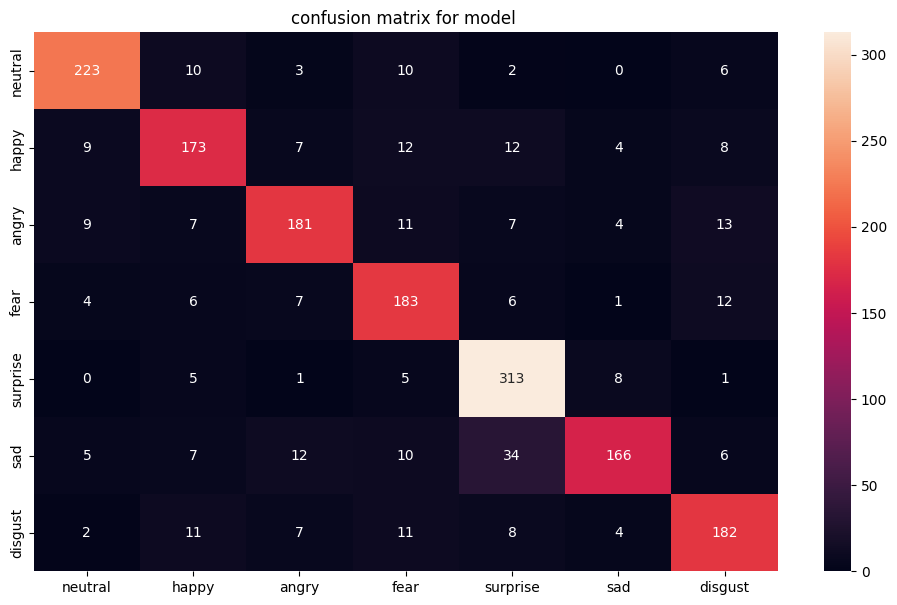

In [56]:
conf=confusion_matrix(y_check,y_pred)
cm=pd.DataFrame(
    conf,index=[i for i in emotion_names],
    columns=[i for i in emotion_names]
)
plt.figure(figsize=(12,7))
ax=sns.heatmap(cm,annot=True,fmt='d')
ax.set_title(f'confusion matrix for model ')
plt.show()

In [57]:
print(f'Model Confusion Matrix\n',classification_report(y_check,y_pred,target_names=emotion_names))

Model Confusion Matrix
               precision    recall  f1-score   support

     neutral       0.88      0.88      0.88       254
       happy       0.79      0.77      0.78       225
       angry       0.83      0.78      0.80       232
        fear       0.76      0.84      0.79       219
    surprise       0.82      0.94      0.88       333
         sad       0.89      0.69      0.78       240
     disgust       0.80      0.81      0.80       225

    accuracy                           0.82      1728
   macro avg       0.82      0.81      0.82      1728
weighted avg       0.83      0.82      0.82      1728



In [59]:
model_path = "./res_model.keras"
model.save(model_path)

In [60]:
from google.colab import files
files.download('./res_model.keras')
files.download('scaler.save')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Testing

In [70]:
import pandas as pd
import numpy as np
import librosa
import os
import joblib
from tensorflow.keras.models import load_model
from sklearn.preprocessing import LabelEncoder

# Load the trained model and scaler
model = load_model('res_model.keras')
scaler = joblib.load('scaler.save')

emotion_names = main_df['Emotion'].unique()
lb = LabelEncoder()
lb.fit(emotion_names)

correct_predictions = {emotion: [] for emotion in emotion_names}

for emotion in emotion_names:
    emotion_samples = main_df[main_df['Emotion'] == emotion].sample(n=min(5, len(main_df[main_df['Emotion'] == emotion])), random_state=42)

    for _, row in emotion_samples.iterrows():
        file_path = row['File_Path']
        true_emotion = row['Emotion']

        # Extract features
        features = get_features(file_path)
        if features is None:
            continue  # Skip if feature extraction fails

        # Scale and reshape features for prediction
        features = scaler.transform([features])
        features = np.expand_dims(features, axis=2)

        # Predict emotion
        pred = model.predict(features, verbose=0)
        pred_index = np.argmax(pred, axis=1)[0]
        pred_label = lb.inverse_transform([pred_index])[0]
        pred_prob = pred[0][pred_index]

        # Check if prediction is correct
        if pred_label == true_emotion:
            file_name = file_path
            correct_predictions[true_emotion].append((file_name, pred_prob))

for emotion in emotion_names:
    print(f"\nCorrectly predicted file names for {emotion}:")
    if len(correct_predictions[emotion]) == 0:
        print("No correct predictions for this emotion.")
    else:
        for file_name, prob in correct_predictions[emotion][:5]:
            print(f"{file_name} ({emotion}, Probability: {prob:.4f})")


Correctly predicted file names for neutral:
Ravdess/audio_speech_actors_01-24/Actor_01/03-01-02-01-02-02-01.wav (neutral, Probability: 0.9999)
Ravdess/audio_speech_actors_01-24/Actor_09/03-01-01-01-01-01-09.wav (neutral, Probability: 0.9663)
Ravdess/audio_speech_actors_01-24/Actor_05/03-01-02-01-01-01-05.wav (neutral, Probability: 0.9992)
Ravdess/audio_speech_actors_01-24/Actor_01/03-01-02-02-01-01-01.wav (neutral, Probability: 0.9996)
Ravdess/audio_speech_actors_01-24/Actor_15/03-01-01-01-01-02-15.wav (neutral, Probability: 0.9609)

Correctly predicted file names for happy:
Ravdess/audio_speech_actors_01-24/Actor_02/03-01-03-01-02-01-02.wav (happy, Probability: 0.9998)
Ravdess/audio_speech_actors_01-24/Actor_17/03-01-03-02-01-02-17.wav (happy, Probability: 0.9934)
Ravdess/audio_speech_actors_01-24/Actor_23/03-01-03-02-02-01-23.wav (happy, Probability: 0.9996)
Ravdess/audio_speech_actors_01-24/Actor_17/03-01-03-02-02-02-17.wav (happy, Probability: 0.9990)
Ravdess/audio_speech_actors_0